<a href="https://colab.research.google.com/github/Mai732/ML-AI/blob/main/assignment10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_moons

plt.style.use('ggplot')

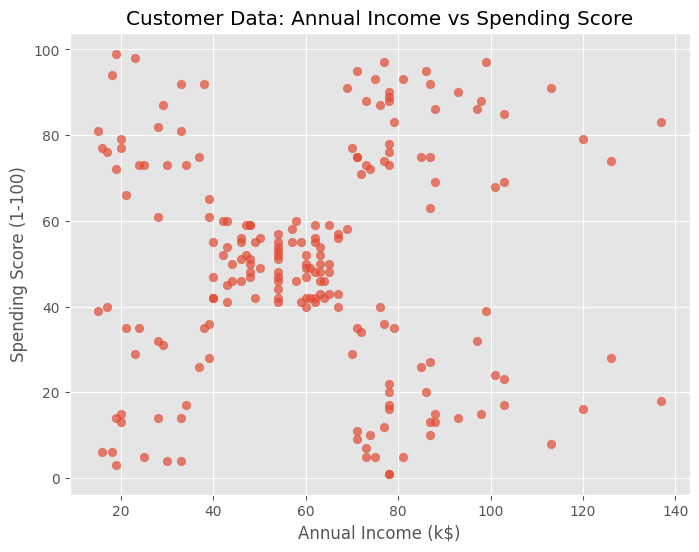

Data shape: (200, 2)
First 5 rows (scaled):
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [ ]:
# Part 1: Loading and preprocessing the data

df = pd.read_csv('Mall_Customers.csv')

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], alpha=0.7)
plt.title('Customer Data: Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

print("Data shape:", X.shape)
print("First 5 rows (scaled):\n", X_scaled[:5])

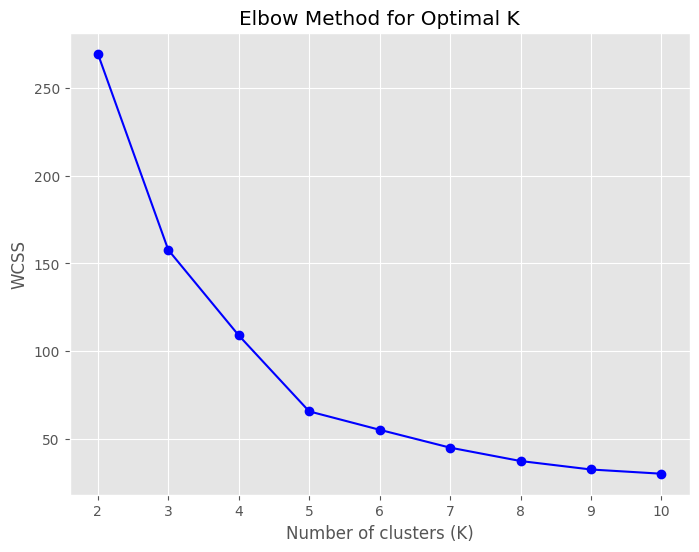

Optimal K chosen: 5
Silhouette Score for K=5: 0.5547
Silhouette Scores:
K=2: 0.3213
K=3: 0.4666
K=4: 0.4939
K=5: 0.5547
K=6: 0.5399
K=7: 0.5281
K=8: 0.4552
K=9: 0.4571
K=10: 0.4432


In [ ]:
# part2
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


    labels = kmeans.labels_
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)


plt.figure(figsize=(8,6))
plt.plot(K_range, wcss, 'bo-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

optimal_k = 5
print(f"Optimal K chosen: {optimal_k}")


print(f"Silhouette Score for K={optimal_k}: {silhouette_scores[optimal_k-2]:.4f}")

print("Silhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: {score:.4f}")

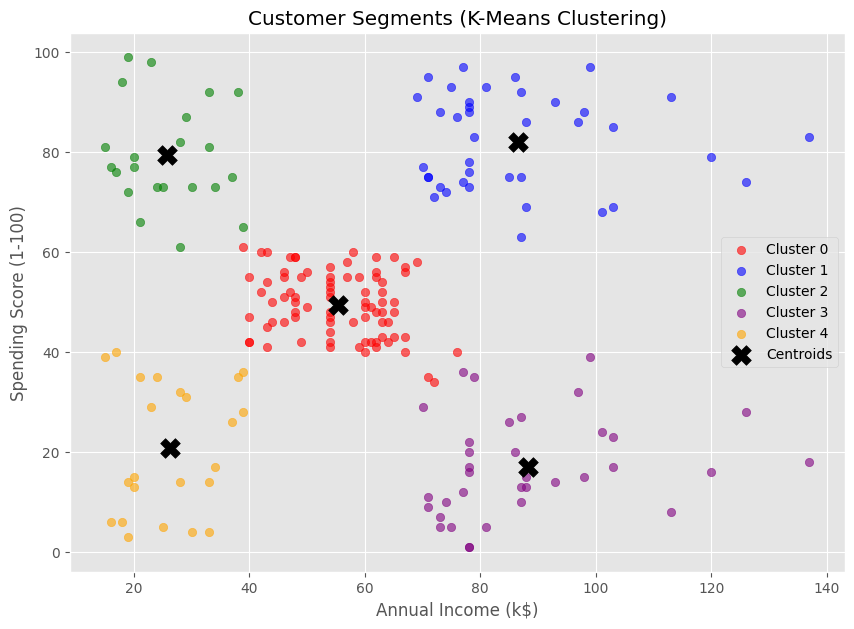

 Cluster Interpretation 
Cluster 0 (Red):   Medium income, high spending
Cluster 1 (Blue):  High income, low spending (careful shoppers)
Cluster 2 (Green): Low income, low spending (economy segment)
Cluster 3 (Purple):High income, high spending (premium segment)
Cluster 4 (Orange):Low income, high spending (aspirational buyers)


In [ ]:
#part3
# Train final K-Means with K=5
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = final_kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters


centroids_original = scaler.inverse_transform(final_kmeans.cluster_centers_)


plt.figure(figsize=(10,7))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(optimal_k):
    plt.scatter(X[clusters == i]['Annual Income (k$)'],
                X[clusters == i]['Spending Score (1-100)'],
                c=colors[i], label=f'Cluster {i}', alpha=0.6)


plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            marker='X', s=200, c='black', label='Centroids')

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()


print(" Cluster Interpretation ")
print("Cluster 0 (Red):   Medium income, high spending")
print("Cluster 1 (Blue):  High income, low spending (careful shoppers)")
print("Cluster 2 (Green): Low income, low spending (economy segment)")
print("Cluster 3 (Purple):High income, high spending (premium segment)")
print("Cluster 4 (Orange):Low income, high spending (aspirational buyers)")

eps=0.2, min_samples=5 → Clusters: 2
eps=0.3, min_samples=5 → Clusters: 2
eps=0.2, min_samples=10 → Clusters: 2
eps=0.3, min_samples=10 → Clusters: 2


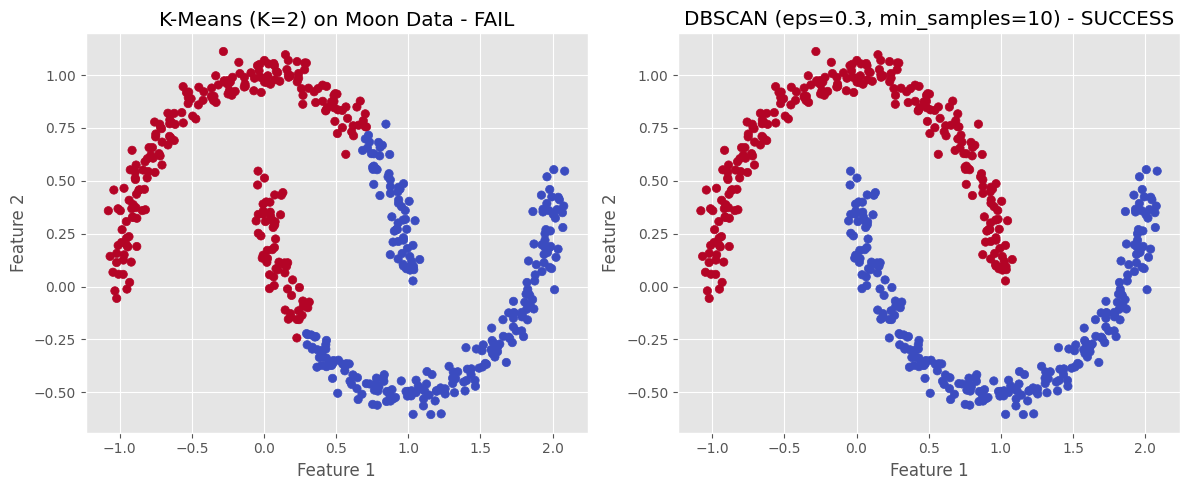

In [ ]:
#part4

X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=42)


kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
moon_clusters_kmeans = kmeans_moons.fit_predict(X_moons)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_moons[:,0], X_moons[:,1], c=moon_clusters_kmeans, cmap='coolwarm')
plt.title('K-Means (K=2) on Moon Data - FAIL')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')


params = [(0.2, 5), (0.3, 5), (0.2, 10), (0.3, 10)]

best_labels = None
best_params = None

for eps, min_samples in params:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_moons)


    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    print(f"eps={eps}, min_samples={min_samples} → Clusters: {n_clusters}")

    if n_clusters == 2:
        best_labels = labels
        best_params = (eps, min_samples)


plt.subplot(1,2,2)
plt.scatter(X_moons[:,0], X_moons[:,1], c=best_labels, cmap='coolwarm')
plt.title(f"DBSCAN (eps={best_params[0]}, min_samples={best_params[1]}) - SUCCESS")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()

In [ ]:
#conclusion

print("CONCLUSION: K-Means vs DBSCAN")
print("""
 K-Means Performance:
   - Works well for spherical, evenly sized clusters (like customer segments)
   - Failed on moon-shaped data because it assumes circular clusters
   - Sensitive to scaling and outliers

DBSCAN Performance:
   - Successfully separated moon-shaped clusters
   - Does not assume spherical shapes
   - Can identify noise points (labeled -1)
   - Requires tuning of eps (neighborhood radius) and min_samples

 Recommendation for Customer Data:
   - K-Means is appropriate for the mall dataset (globular segments)
   - For irregular shapes (e.g., purchase patterns over time), consider DBSCAN
""")